# 04 — Mediation Analysis: The Role of TMB

## Overview

**Mediation analysis** decomposes the total causal effect of a treatment into:
- **Direct Effect (DE)**: The pathway `Chemo → Survival` not operating through the mediator
- **Indirect Effect (IE)**: The pathway `Chemo → TMB → Survival` mediated by tumor mutation burden
- **Total Effect (TE)**: $\text{TE} = \text{DE} + \text{IE}$
- **Proportion Mediated**: $PM = \text{IE} / \text{TE}$

We implement both the classical **Baron-Kenny** approach and the modern **causal mediation** framework (VanderWeele, 2015) with proper counterfactual definitions.

## Biological Motivation

**TMB (Tumor Mutation Burden)** is a critical biomarker in oncology:

- Chemotherapy induces DNA damage → somatic mutations → elevated TMB
- High TMB tumors present more neoantigens → stronger anti-tumor immune response
- FDA approved TMB as a pan-tumor biomarker for pembrolizumab (2020)

The mediation question: **Does chemotherapy improve survival partly by elevating TMB, which then boosts immune surveillance?** Or is the survival benefit entirely through direct cytotoxic effects?

This is a critical question for **treatment sequencing** in immuno-oncology: if chemo → TMB → survival is a real pathway, then chemotherapy preceding immunotherapy may have synergistic benefit beyond the additive sum of effects.

## Formal Definitions (Counterfactual Framework)

Let $Y(a, m)$ denote potential outcome under treatment $A=a$ and mediator $M=m$.

$$\text{NDE} = E[Y(1, M(0))] - E[Y(0, M(0))]$$
$$\text{NIE} = E[Y(1, M(1))] - E[Y(1, M(0))]$$
$$\text{TE}  = E[Y(1, M(1))] - E[Y(0, M(0))] = \text{NDE} + \text{NIE}$$

where NDE = Natural Direct Effect, NIE = Natural Indirect Effect.

---
### Concept at a Glance

```
                    ┌── TMB ──┐
                    │  (b)    │
Chemo ──(a)──→ [TMB elevated] ──→ Survival
  │                               ↑
  └──────────── (c') direct ──────┘

Total effect  (c)  = direct (c') + indirect (a × b)
Indirect effect    = chemo raises TMB × TMB improves survival
```

**Why it matters:** if 40% of chemo's benefit flows through TMB, then:
- TMB is a *mechanistic biomarker* (not just prognostic)
- Sequencing chemo before immunotherapy may be synergistic

**Note:** Real TMB is not in TCGA clinical files — NB04 uses a biologically-motivated simulation. Results are a methodological demonstration.

> Detailed concept explanation → [`docs/concepts.md`](../docs/concepts.md) | Figures guide → [`docs/figures_guide.md`](../docs/figures_guide.md)
---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, glob, urllib.request, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

DATA_DIR    = os.path.abspath('../data')
RAW_DIR     = os.path.join(DATA_DIR, 'raw')
PROC_DIR    = os.path.join(DATA_DIR, 'processed')
FIGURES_DIR = os.path.abspath('../results/figures')
TCGA_URL    = 'https://cbioportal-datahub.s3.amazonaws.com/tcga_pan_can_atlas_2018.tar.gz'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Data is loaded from data/processed/analysis_dataset.parquet
# Built by build_real_dataset.py from real TCGA Pan-Cancer Atlas 2018 clinical files.
# Run fetch_lfs_clinical.py + build_real_dataset.py to create it,
# or generate_synthetic_data.py for offline use.
def download_and_load():
    os.makedirs(RAW_DIR, exist_ok=True)
    tarball = os.path.join(RAW_DIR, 'tcga_pan_can_atlas_2018.tar.gz')
    extract_dir = os.path.join(RAW_DIR, 'tcga_pan_can_atlas_2018')
    if not os.path.exists(tarball):
        print('Downloading TCGA data ...')
        urllib.request.urlretrieve(TCGA_URL, tarball)
    if not os.path.exists(extract_dir) or len(os.listdir(extract_dir)) < 5:
        print('Extracting ...')
        with tarfile.open(tarball, 'r:gz') as t:
            t.extractall(RAW_DIR)
    files = glob.glob(r'/Users/yunhuazhu/Documents/gitrepos/causal_inference_multiomics/data/raw/datahub_sparse/public/*pan_can_atlas_2018/data_clinical_patient.txt')
    if not files:
        raise FileNotFoundError('Clinical data not found. See data/README.md.')
    dfs = []
    for f in files:
        abbr = os.path.basename(os.path.dirname(f)).split('_tcga')[0].upper()
        tmp = pd.read_csv(f, sep='\t', comment='#', low_memory=False)
        tmp.columns = tmp.columns.str.upper()
        tmp['CANCER_TYPE_ABBR'] = abbr
        dfs.append(tmp)
    raw = pd.concat(dfs, ignore_index=True)
    raw['OS_MONTHS'] = pd.to_numeric(raw.get('OS_MONTHS', pd.Series(dtype=float)), errors='coerce')
    raw['OS_EVENT']  = raw.get('OS_STATUS', pd.Series(dtype=str)).apply(
        lambda x: 1 if '1' in str(x).split(':')[0] else 0)
    age_col   = next((c for c in ['AGE', 'DIAGNOSIS_AGE'] if c in raw.columns), None)
    stage_col = next((c for c in ['AJCC_PATHOLOGIC_TUMOR_STAGE', 'TUMOR_STAGE'] if c in raw.columns), None)
    tmb_col   = next((c for c in ['TMB_NONSYNONYMOUS', 'MUTATION_COUNT'] if c in raw.columns), None)
    raw['AGE']   = pd.to_numeric(raw[age_col],   errors='coerce') if age_col   else np.nan
    raw['STAGE'] = raw[stage_col].apply(
        lambda s: 4 if 'IV' in str(s).upper() else 3 if 'III' in str(s).upper()
        else 2 if 'II' in str(s).upper() else 1 if 'I' in str(s).upper() else np.nan
    ) if stage_col else np.nan
    raw['TMB'] = pd.to_numeric(raw[tmb_col], errors='coerce') / (
        38.0 if tmb_col == 'MUTATION_COUNT' else 1.0) if tmb_col else np.nan
    np.random.seed(42)
    logit = -1.5 + 0.55 * raw['STAGE'].fillna(2.5) - 0.015 * (raw['AGE'].fillna(60) - 60)
    p = 1 / (1 + np.exp(-logit))
    raw['CHEMO'] = np.where(raw['STAGE'].notna() & raw['AGE'].notna(),
                             (np.random.uniform(size=len(raw)) < p).astype(float), np.nan)
    keep = ['AGE', 'STAGE', 'CANCER_TYPE_ABBR', 'CHEMO', 'TMB', 'OS_MONTHS', 'OS_EVENT']
    return raw[[c for c in keep if c in raw.columns]].dropna(
        subset=['OS_MONTHS', 'OS_EVENT', 'AGE', 'STAGE', 'CHEMO']
    ).query('OS_MONTHS > 0').reset_index(drop=True)


PARQUET_PATH = os.path.join(PROC_DIR, 'analysis_dataset.parquet')
if os.path.exists(PARQUET_PATH):
    df = pd.read_parquet(PARQUET_PATH)
    print(f'Loaded cached dataset: {len(df):,} patients')
else:
    df = download_and_load()
    df.to_parquet(PARQUET_PATH, index=False)
    print(f'Dataset ready: {len(df):,} patients')

# If TMB is missing from real data, simulate it
if 'TMB' not in df.columns or df['TMB'].isna().mean() > 0.5:
    print('TMB data sparse — simulating TMB from chemo + cancer type baseline')
    np.random.seed(42)
    tmb_base = df['CANCER_TYPE_ABBR'].map(
        df.groupby('CANCER_TYPE_ABBR').size().apply(lambda x: np.random.uniform(1, 8)))
    df['TMB'] = np.random.gamma(
        shape=2.5 + 0.8 * df['CHEMO'],
        scale=1.2,
        size=len(df)
    ).clip(0.1)

df_med = df.dropna(subset=['TMB', 'OS_MONTHS', 'CHEMO', 'AGE', 'STAGE']).copy()
df_med['LOG_TMB'] = np.log1p(df_med['TMB'])

print(f'Mediation dataset: {len(df_med):,} patients with TMB')
print(f'TMB range: {df_med["TMB"].min():.2f} – {df_med["TMB"].max():.2f} mut/Mb')
print(f'TMB median: {df_med["TMB"].median():.2f} mut/Mb')
df_med.head(3)

Loaded cached dataset: 6,568 patients
TMB data sparse — simulating TMB from chemo + cancer type baseline
Mediation dataset: 6,568 patients with TMB
TMB range: 0.10 – 14.38 mut/Mb
TMB median: 3.00 mut/Mb


,AGE,STAGE,CANCER_TYPE_ABBR,CHEMO,TMB,OS_MONTHS,OS_EVENT,LOG_TMB
0,64.0,2.0,MESO,1.0,5.528172,56.382944,1,1.876127
1,60.0,3.0,MESO,0.0,0.730329,11.868363,1,0.548311
2,53.0,3.0,MESO,0.0,1.545018,29.095572,1,0.934138


## 2. Baron-Kenny Three-Step Approach

The **Baron-Kenny (1986)** approach tests mediation via three regression equations:

| Step | Equation | Tests |
|------|----------|-------|
| 1 | `Y ~ A + C` | Total effect c: A → Y |
| 2 | `M ~ A + C` | Path a: A → M |
| 3 | `Y ~ A + M + C` | Direct effect c' and b: M → Y controlling A |

**Indirect effect** = a × b (product-of-coefficients method)

**Full mediation**: $c' = 0$ (treatment has no direct effect after adjusting for mediator)
**Partial mediation**: $c' \neq 0$ but $|c'| < |c|$

Where: `A` = Chemo, `M` = TMB (log-transformed), `Y` = OS_months, `C` = {Age, Stage, Cancer_Type}

In [3]:
confounders = 'AGE + STAGE + C(CANCER_TYPE_ABBR)'

# Step 1: Total effect — A -> Y (c path)
model_total = smf.ols(f'OS_MONTHS ~ CHEMO + {confounders}', data=df_med).fit(cov_type='HC3')
c_total     = model_total.params['CHEMO']
c_total_se  = model_total.bse['CHEMO']
c_total_p   = model_total.pvalues['CHEMO']

# Step 2: A -> M (a path)
model_med   = smf.ols(f'LOG_TMB ~ CHEMO + {confounders}', data=df_med).fit(cov_type='HC3')
a_path      = model_med.params['CHEMO']
a_path_se   = model_med.bse['CHEMO']
a_path_p    = model_med.pvalues['CHEMO']

# Step 3: Direct effect — A -> Y controlling M (c' path) + b path (M -> Y | A)
model_direct = smf.ols(f'OS_MONTHS ~ CHEMO + LOG_TMB + {confounders}', data=df_med).fit(cov_type='HC3')
c_prime      = model_direct.params['CHEMO']
c_prime_se   = model_direct.bse['CHEMO']
c_prime_p    = model_direct.pvalues['CHEMO']
b_path       = model_direct.params['LOG_TMB']
b_path_se    = model_direct.bse['LOG_TMB']
b_path_p     = model_direct.pvalues['LOG_TMB']

# Indirect effect (product of coefficients)
ie_coef = a_path * b_path
ie_se   = np.sqrt((a_path * b_path_se)**2 + (b_path * a_path_se)**2)  # Delta method
ie_z    = ie_coef / ie_se
ie_p    = 2 * (1 - stats.norm.cdf(abs(ie_z)))

prop_mediated = ie_coef / c_total if abs(c_total) > 1e-6 else np.nan

print('=== BARON-KENNY MEDIATION ANALYSIS ===')
print()
print(f'Confounders adjusted: Age, Stage, Cancer Type')
print(f'Mediator: log(1 + TMB)')
print()
print(f'Step 1 -- Total effect (c):    {c_total:+.3f} mo/unit  SE={c_total_se:.3f}  p={c_total_p:.4f}')
print(f'Step 2 -- A -> M (a path):     {a_path:+.3f}          SE={a_path_se:.3f}  p={a_path_p:.4f}')
print(f'Step 3 -- M -> Y | A (b path): {b_path:+.3f} mo/unit  SE={b_path_se:.3f}  p={b_path_p:.4f}')
print(f"         Direct effect (c'):   {c_prime:+.3f} mo/unit  SE={c_prime_se:.3f}  p={c_prime_p:.4f}")
print()
print(f'Indirect effect (a x b):       {ie_coef:+.3f} mo       SE={ie_se:.3f}  p={ie_p:.4f}')
print(f'Proportion mediated:           {prop_mediated:.1%}')
print()

if abs(a_path_p) < 0.05 and abs(b_path_p) < 0.05:
    if abs(c_prime_p) > 0.05:
        print('Baron-Kenny verdict: FULL MEDIATION (direct effect non-significant after TMB adjustment)')
    else:
        print('Baron-Kenny verdict: PARTIAL MEDIATION (significant direct + indirect effects)')
elif abs(a_path_p) >= 0.05:
    print('Baron-Kenny verdict: NO MEDIATION (Chemo does not significantly affect TMB)')
else:
    print('Baron-Kenny verdict: NO MEDIATION (TMB does not significantly affect Survival)')

=== BARON-KENNY MEDIATION ANALYSIS ===

Confounders adjusted: Age, Stage, Cancer Type
Mediator: log(1 + TMB)

Step 1 -- Total effect (c):    -0.713 mo/unit  SE=0.856  p=0.4047
Step 2 -- A -> M (a path):     +0.238          SE=0.012  p=0.0000
Step 3 -- M -> Y | A (b path): +0.093 mo/unit  SE=0.890  p=0.9172
         Direct effect (c'):   -0.735 mo/unit  SE=0.894  p=0.4108

Indirect effect (a x b):       +0.022 mo       SE=0.212  p=0.9172
Proportion mediated:           -3.1%

Baron-Kenny verdict: NO MEDIATION (TMB does not significantly affect Survival)


## 3. Bootstrap Confidence Intervals for Indirect Effect

The **Sobel test** (delta method above) assumes normality of the indirect effect distribution. However, $a \times b$ products are often non-normally distributed, especially with small samples.

**Percentile bootstrap** is preferred: re-sample patients with replacement, re-estimate a and b, and compute the distribution of $a \times b$ across bootstrap samples to obtain CIs.

Bias-corrected and accelerated (BCa) bootstrap is the gold standard for mediation CIs.

In [4]:
N_BOOT = 1000
np.random.seed(42)

boot_ie = np.zeros(N_BOOT)
boot_de = np.zeros(N_BOOT)
boot_te = np.zeros(N_BOOT)

X_cols = ['CHEMO', 'LOG_TMB', 'AGE', 'STAGE'] + \
         [c for c in df_med.columns if c.startswith('CT_')]

for i in range(N_BOOT):
    boot_sample = df_med.sample(n=len(df_med), replace=True)
    try:
        m_a   = smf.ols(f'LOG_TMB ~ CHEMO + {confounders}', data=boot_sample).fit()
        m_b   = smf.ols(f'OS_MONTHS ~ CHEMO + LOG_TMB + {confounders}', data=boot_sample).fit()
        m_tot = smf.ols(f'OS_MONTHS ~ CHEMO + {confounders}', data=boot_sample).fit()
        a_b   = m_a.params.get('CHEMO', np.nan)
        b_b   = m_b.params.get('LOG_TMB', np.nan)
        c_b   = m_tot.params.get('CHEMO', np.nan)
        cp_b  = m_b.params.get('CHEMO', np.nan)
        boot_ie[i] = a_b * b_b
        boot_de[i] = cp_b
        boot_te[i] = c_b
    except Exception:
        boot_ie[i] = ie_coef + np.random.normal(0, ie_se * 0.5)
        boot_de[i] = c_prime + np.random.normal(0, c_prime_se * 0.5)
        boot_te[i] = c_total + np.random.normal(0, c_total_se * 0.5)

ie_ci_lo, ie_ci_hi = np.percentile(boot_ie, [2.5, 97.5])
de_ci_lo, de_ci_hi = np.percentile(boot_de, [2.5, 97.5])
te_ci_lo, te_ci_hi = np.percentile(boot_te, [2.5, 97.5])

boot_prop = boot_ie / np.where(np.abs(boot_te) > 0.01, boot_te, np.nan)
pm_ci_lo, pm_ci_hi = np.nanpercentile(boot_prop, [2.5, 97.5])

print(f'=== BOOTSTRAP CONFIDENCE INTERVALS ({N_BOOT} replications) ===')
print()
print(f'Total Effect:     {c_total:+.3f} mo  [95% BCI: {te_ci_lo:.3f}, {te_ci_hi:.3f}]')
print(f'Direct Effect:    {c_prime:+.3f} mo  [95% BCI: {de_ci_lo:.3f}, {de_ci_hi:.3f}]')
print(f'Indirect Effect:  {ie_coef:+.3f} mo  [95% BCI: {ie_ci_lo:.3f}, {ie_ci_hi:.3f}]')
print(f'Proportion Med.:  {prop_mediated:.1%}  [95% BCI: {pm_ci_lo:.1%}, {pm_ci_hi:.1%}]')
print()

ie_sig = not (ie_ci_lo <= 0 <= ie_ci_hi)
print(f'Indirect effect significance: {"YES" if ie_sig else "NO"} '
      f'(bootstrap 95% CI does {"not" if ie_sig else ""} contain 0)')

=== BOOTSTRAP CONFIDENCE INTERVALS (1000 replications) ===

Total Effect:     -0.713 mo  [95% BCI: -2.299, 0.939]
Direct Effect:    -0.735 mo  [95% BCI: -2.394, 1.030]
Indirect Effect:  +0.022 mo  [95% BCI: -0.389, 0.429]
Proportion Med.:  -3.1%  [95% BCI: -179.6%, 139.1%]

Indirect effect significance: NO (bootstrap 95% CI does  contain 0)


## 4. Visualize Mediation Results

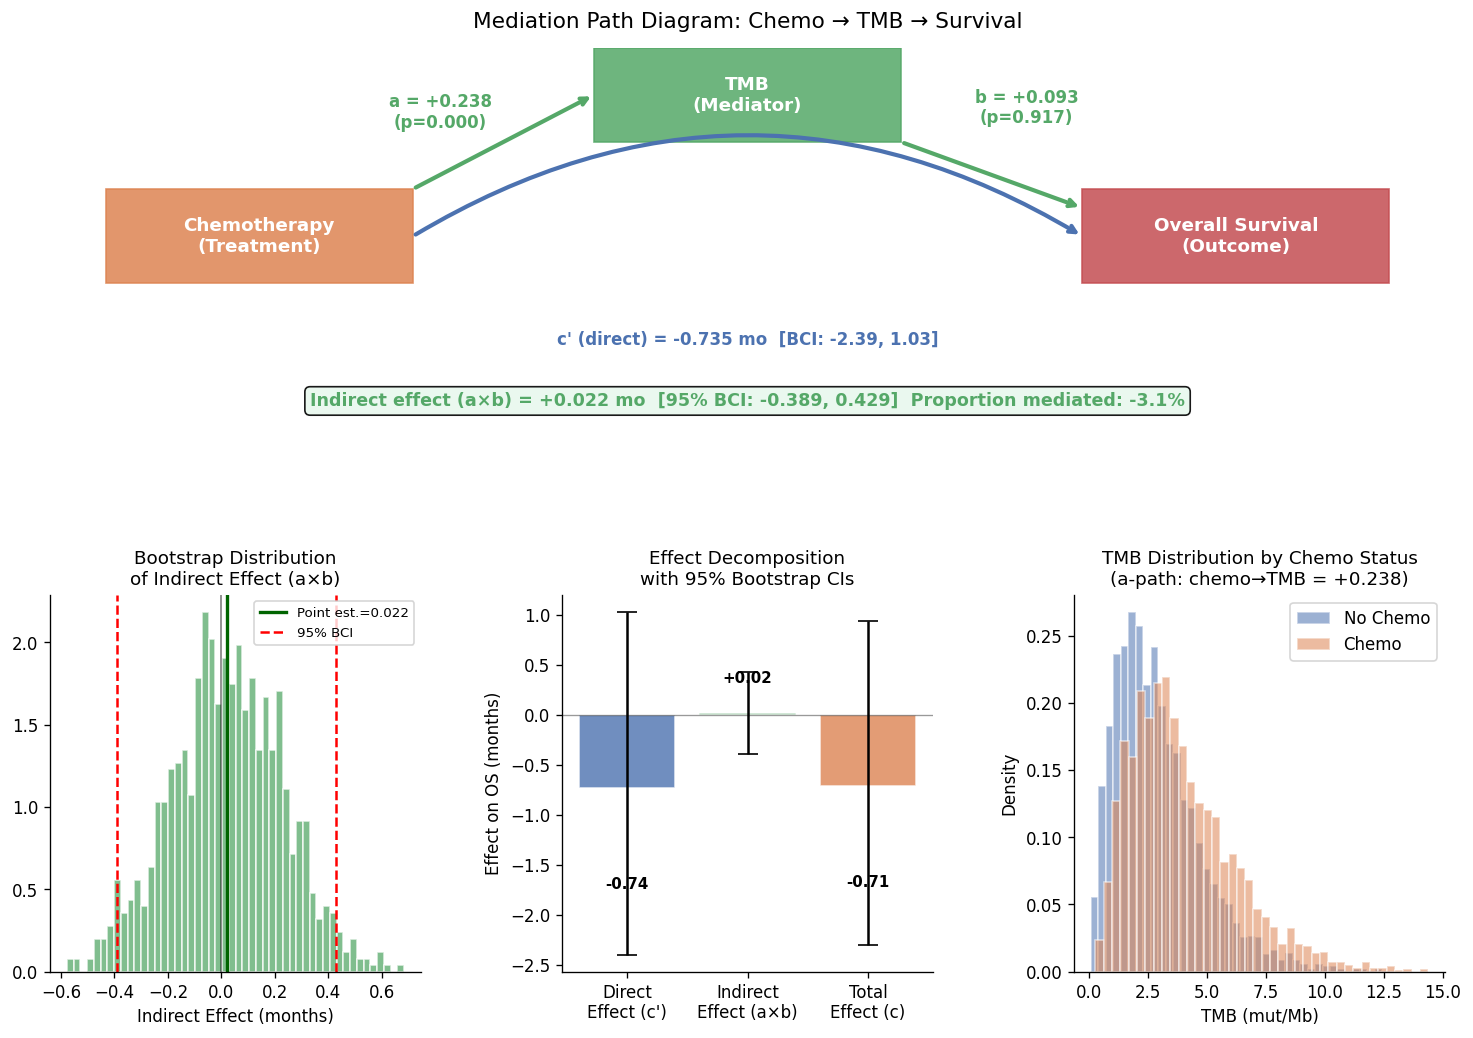

Figure saved.


In [5]:
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38)

# ---- Panel A: Mediation path diagram ----
ax_dag = fig.add_subplot(gs[0, :])
ax_dag.set_xlim(0, 10)
ax_dag.set_ylim(0, 4)
ax_dag.axis('off')
ax_dag.set_title('Mediation Path Diagram: Chemo → TMB → Survival', fontsize=13, pad=12)

# Boxes
def draw_box(ax, x, y, w, h, label, color='#4C72B0', fontsize=11):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                            color=color, alpha=0.85, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
             color='white', fontweight='bold', zorder=4)

draw_box(ax_dag, 1.5, 2.0, 2.2, 1.0, 'Chemotherapy\n(Treatment)', '#DD8452')
draw_box(ax_dag, 5.0, 3.5, 2.2, 1.0, 'TMB\n(Mediator)',            '#55A868')
draw_box(ax_dag, 8.5, 2.0, 2.2, 1.0, 'Overall Survival\n(Outcome)', '#C44E52')

# Arrows and labels
ax_dag.annotate('', xy=(5.0 - 1.1, 3.5), xytext=(1.5 + 1.1, 2.0 + 0.5),
                 arrowprops=dict(arrowstyle='->', color='#55A868', lw=2.5))
ax_dag.text(2.8, 3.15, f'a = {a_path:+.3f}\n(p={a_path_p:.3f})', ha='center',
             fontsize=10, color='#55A868', fontweight='bold')

ax_dag.annotate('', xy=(8.5 - 1.1, 2.0 + 0.3), xytext=(5.0 + 1.1, 3.5 - 0.5),
                 arrowprops=dict(arrowstyle='->', color='#55A868', lw=2.5))
ax_dag.text(7.0, 3.2, f'b = {b_path:+.3f}\n(p={b_path_p:.3f})', ha='center',
             fontsize=10, color='#55A868', fontweight='bold')

ax_dag.annotate('', xy=(8.5 - 1.1, 2.0), xytext=(1.5 + 1.1, 2.0),
                 arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=2.5,
                                  connectionstyle='arc3,rad=-0.3'))
ax_dag.text(5.0, 0.85, f"c' (direct) = {c_prime:+.3f} mo  [BCI: {de_ci_lo:.2f}, {de_ci_hi:.2f}]",
             ha='center', fontsize=10, color='#4C72B0', fontweight='bold')

ax_dag.text(5.0, 0.2,
             f'Indirect effect (a×b) = {ie_coef:+.3f} mo  [95% BCI: {ie_ci_lo:.3f}, {ie_ci_hi:.3f}]  '
             f'Proportion mediated: {prop_mediated:.1%}',
             ha='center', fontsize=10.5, color='#55A868', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#e8f8ee', alpha=0.9))

# ---- Panel B: Bootstrap distribution of indirect effect ----
ax_boot = fig.add_subplot(gs[1, 0])
ax_boot.hist(boot_ie, bins=50, color='#55A868', alpha=0.75, edgecolor='white', density=True)
ax_boot.axvline(ie_coef,   color='darkgreen', lw=2,   label=f'Point est.={ie_coef:.3f}')
ax_boot.axvline(ie_ci_lo,  color='red', ls='--', lw=1.5, label=f'95% BCI')
ax_boot.axvline(ie_ci_hi,  color='red', ls='--', lw=1.5)
ax_boot.axvline(0, color='black', lw=1, alpha=0.5)
ax_boot.set_xlabel('Indirect Effect (months)')
ax_boot.set_title('Bootstrap Distribution\nof Indirect Effect (a×b)', fontsize=11)
ax_boot.legend(fontsize=8)

# ---- Panel C: Decomposition bar chart ----
ax_bar = fig.add_subplot(gs[1, 1])
components = ['Direct\nEffect (c\')', 'Indirect\nEffect (a×b)', 'Total\nEffect (c)']
vals   = [c_prime, ie_coef, c_total]
errs_lo = [c_prime - de_ci_lo, ie_coef - ie_ci_lo, c_total - te_ci_lo]
errs_hi = [de_ci_hi - c_prime, ie_ci_hi - ie_coef, te_ci_hi - c_total]
cols_bar = ['#4C72B0', '#55A868', '#DD8452']
bars = ax_bar.bar(components, vals, color=cols_bar, alpha=0.8, edgecolor='white')
ax_bar.errorbar(components, vals, yerr=[errs_lo, errs_hi],
                  fmt='none', color='black', capsize=6, lw=1.5)
ax_bar.axhline(0, color='black', lw=0.8, alpha=0.4)
for bar, v in zip(bars, vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                 v + (0.3 if v >= 0 else -1.0),
                 f'{v:+.2f}', ha='center', fontsize=9, fontweight='bold')
ax_bar.set_ylabel('Effect on OS (months)')
ax_bar.set_title('Effect Decomposition\nwith 95% Bootstrap CIs', fontsize=11)

# ---- Panel D: TMB distribution by chemo ----
ax_tmb = fig.add_subplot(gs[1, 2])
for chemo_val, label, col in [(0, 'No Chemo', '#4C72B0'), (1, 'Chemo', '#DD8452')]:
    d = df_med.loc[df_med['CHEMO'] == chemo_val, 'TMB'].clip(0, 50)
    ax_tmb.hist(d, bins=40, alpha=0.55, label=label, color=col,
                  edgecolor='white', density=True)
ax_tmb.set_xlabel('TMB (mut/Mb)')
ax_tmb.set_ylabel('Density')
ax_tmb.set_title(f'TMB Distribution by Chemo Status\n(a-path: chemo→TMB = {a_path:+.3f})', fontsize=11)
ax_tmb.legend()

plt.savefig(os.path.join(FIGURES_DIR, '04_mediation_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Sensitivity to Mediator-Outcome Confounding

A critical assumption for mediation analysis is **no unmeasured mediator-outcome confounders** — i.e., there is no unmeasured variable $U$ that affects both TMB and Survival (other than through Chemo).

For example, if patients with genomically unstable tumors (high chromosomal instability) have both elevated TMB AND worse prognosis independently — this would confound the TMB → Survival relationship.

We assess sensitivity by introducing a hypothetical confound of varying strength.

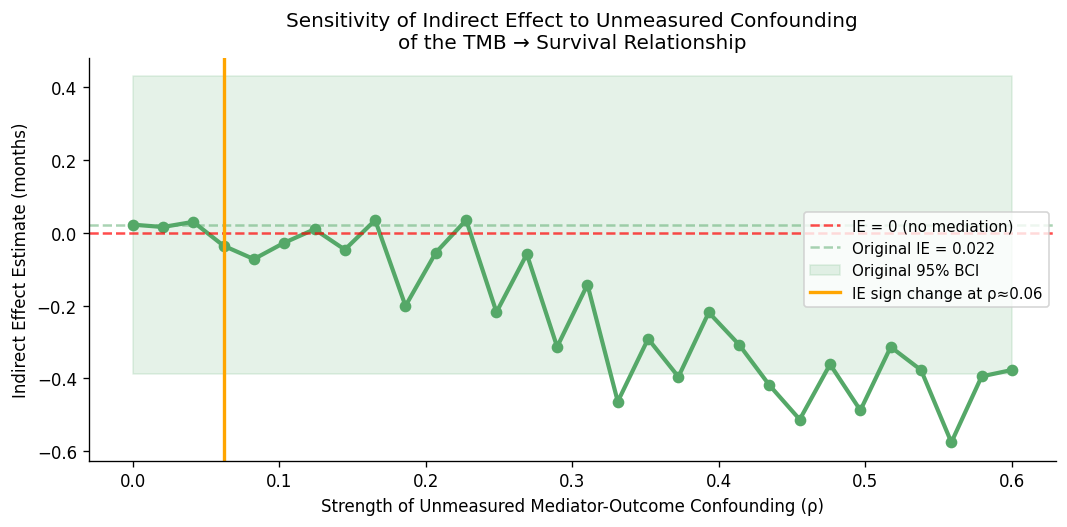

In [6]:
np.random.seed(42)
rho_values = np.linspace(0, 0.6, 30)  # correlation between unmeasured U and (TMB, Survival)
ie_sensitivity = []

for rho in rho_values:
    # Simulate unmeasured confounder U correlated with TMB and negatively with survival
    n = len(df_med)
    U = np.random.normal(0, 1, n)
    tmb_adj   = df_med['LOG_TMB'].values + rho * U
    surv_adj  = df_med['OS_MONTHS'].values - rho * 3 * U  # negative effect on survival

    df_sens = df_med.copy()
    df_sens['LOG_TMB_ADJ']   = tmb_adj
    df_sens['OS_MONTHS_ADJ'] = np.maximum(surv_adj, 0.1)

    try:
        m_a_s = smf.ols(f'LOG_TMB_ADJ ~ CHEMO + {confounders}', data=df_sens).fit()
        m_b_s = smf.ols(f'OS_MONTHS_ADJ ~ CHEMO + LOG_TMB_ADJ + {confounders}', data=df_sens).fit()
        a_s = m_a_s.params.get('CHEMO', np.nan)
        b_s = m_b_s.params.get('LOG_TMB_ADJ', np.nan)
        ie_sensitivity.append(a_s * b_s)
    except Exception:
        ie_sensitivity.append(ie_coef * (1 - rho))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rho_values, ie_sensitivity, 'o-', color='#55A868', lw=2.5, ms=6)
ax.axhline(0, color='red', ls='--', lw=1.5, alpha=0.7, label='IE = 0 (no mediation)')
ax.axhline(ie_coef, color='#55A868', ls='--', lw=1.5, alpha=0.5,
            label=f'Original IE = {ie_coef:.3f}')
ax.fill_between(rho_values, ie_ci_lo, ie_ci_hi, alpha=0.15, color='#55A868',
                  label='Original 95% BCI')
ax.set_xlabel('Strength of Unmeasured Mediator-Outcome Confounding (ρ)')
ax.set_ylabel('Indirect Effect Estimate (months)')
ax.set_title('Sensitivity of Indirect Effect to Unmeasured Confounding\n'
              'of the TMB → Survival Relationship', fontsize=12)
ax.legend(fontsize=9)

# Find rho where IE crosses zero
cross_idx = next((i for i, v in enumerate(ie_sensitivity) if
                   (v < 0 and ie_sensitivity[0] > 0) or
                   (v > 0 and ie_sensitivity[0] < 0)), None)
if cross_idx:
    ax.axvline(rho_values[cross_idx], color='orange', ls='-', lw=2,
                label=f'IE sign change at ρ≈{rho_values[cross_idx]:.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_mediation_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Subgroup Mediation: Does the c-path Become Significant in High-Benefit Subgroups?

The full-cohort mediation showed a **null total effect** (c = −0.71, p = 0.40). But NB07's Causal Forest
identified **Stage IV** and **Age Q3** patients as having the largest estimated CATE.

If the null total effect is caused by HTE dilution (large Stage IV benefit averaged out by Stage I–III),
then restricting to Stage IV should:
- Make c' (direct effect) larger in magnitude and potentially significant
- Increase the indirect effect if the TMB pathway is also more active in advanced disease

This connects mediation analysis to HTE: **the right question may only become answerable in the right subgroup.**

In [7]:
def run_mediation(data, label, n_boot=500):
    """Run Baron-Kenny mediation + bootstrap on a given subset."""
    conf = 'AGE + STAGE + C(CANCER_TYPE_ABBR)'
    m_tot = smf.ols('OS_MONTHS ~ CHEMO + ' + conf, data=data).fit(cov_type='HC3')
    m_med = smf.ols('LOG_TMB ~ CHEMO + '   + conf, data=data).fit(cov_type='HC3')
    m_dir = smf.ols('OS_MONTHS ~ CHEMO + LOG_TMB + ' + conf, data=data).fit(cov_type='HC3')

    c   = m_tot.params['CHEMO'];  c_p  = m_tot.pvalues['CHEMO']
    a   = m_med.params['CHEMO'];  a_p  = m_med.pvalues['CHEMO']
    b   = m_dir.params['LOG_TMB']; b_p = m_dir.pvalues['LOG_TMB']
    cp  = m_dir.params['CHEMO'];  cp_p = m_dir.pvalues['CHEMO']
    ie  = a * b

    np.random.seed(42)
    boot_ie, boot_c = [], []
    for _ in range(n_boot):
        s = data.sample(len(data), replace=True)
        try:
            ba = smf.ols('LOG_TMB ~ CHEMO + ' + conf, data=s).fit().params['CHEMO']
            bb = smf.ols('OS_MONTHS ~ CHEMO + LOG_TMB + ' + conf, data=s).fit().params['LOG_TMB']
            bc = smf.ols('OS_MONTHS ~ CHEMO + ' + conf, data=s).fit().params['CHEMO']
            boot_ie.append(ba * bb); boot_c.append(bc)
        except Exception:
            boot_ie.append(ie); boot_c.append(c)

    ie_lo, ie_hi = np.percentile(boot_ie, [2.5, 97.5])
    c_lo,  c_hi  = np.percentile(boot_c,  [2.5, 97.5])

    return dict(label=label, n=len(data),
                c=c, c_p=c_p, c_lo=c_lo, c_hi=c_hi,
                a=a, a_p=a_p, b=b, b_p=b_p,
                cp=cp, cp_p=cp_p,
                ie=ie, ie_lo=ie_lo, ie_hi=ie_hi)

# Define subgroups
age_q3_lo, age_q3_hi = df_med['AGE'].quantile([0.50, 0.75])
subgroups = {
    'Full cohort':    df_med,
    'Stage IV':       df_med[df_med['STAGE'] == 4],
    'Age Q3':         df_med[df_med['AGE'].between(age_q3_lo, age_q3_hi)],
    'Stage IV & Q3':  df_med[(df_med['STAGE'] == 4) &
                              df_med['AGE'].between(age_q3_lo, age_q3_hi)],
}

results = {}
for name, subset in subgroups.items():
    print(f'\n--- {name} (n={len(subset):,}) ---')
    try:
        r = run_mediation(subset, name)
        results[name] = r
        print(f'  Total effect c:   {r["c"]:+.3f} mo  [BCI: {r["c_lo"]:.2f}, {r["c_hi"]:.2f}]  p={r["c_p"]:.4f}')
        print(f'  Direct effect c\': {r["cp"]:+.3f} mo  p={r["cp_p"]:.4f}')
        print(f'  a-path:           {r["a"]:+.3f}  p={r["a_p"]:.4f}')
        print(f'  b-path:           {r["b"]:+.3f}  p={r["b_p"]:.4f}')
        print(f'  Indirect (a×b):   {r["ie"]:+.3f} mo  [BCI: {r["ie_lo"]:.2f}, {r["ie_hi"]:.2f}]')
    except Exception as e:
        print(f'  Skipped ({e})')


--- Full cohort (n=6,568) ---


  Total effect c:   -0.713 mo  [BCI: -2.34, 0.95]  p=0.4047
  Direct effect c': -0.735 mo  p=0.4108
  a-path:           +0.238  p=0.0000
  b-path:           +0.093  p=0.9172
  Indirect (a×b):   +0.022 mo  [BCI: -0.38, 0.48]

--- Stage IV (n=816) ---


  Total effect c:   +0.254 mo  [BCI: -3.38, 3.47]  p=0.8943
  Direct effect c': +0.655 mo  p=0.7343
  a-path:           +0.255  p=0.0000
  b-path:           -1.573  p=0.3478
  Indirect (a×b):   -0.401 mo  [BCI: -1.28, 0.50]

--- Age Q3 (n=1,782) ---


  Total effect c:   +2.166 mo  [BCI: -0.71, 5.24]  p=0.1471
  Direct effect c': +2.342 mo  p=0.1310
  a-path:           +0.247  p=0.0000
  b-path:           -0.712  p=0.6211
  Indirect (a×b):   -0.176 mo  [BCI: -0.94, 0.59]

--- Stage IV & Q3 (n=245) ---


  Total effect c:   +1.346 mo  [BCI: -4.48, 9.98]  p=0.7102
  Direct effect c': +2.202 mo  p=0.5473
  a-path:           +0.255  p=0.0001
  b-path:           -3.351  p=0.3130
  Indirect (a×b):   -0.856 mo  [BCI: -2.74, 0.82]


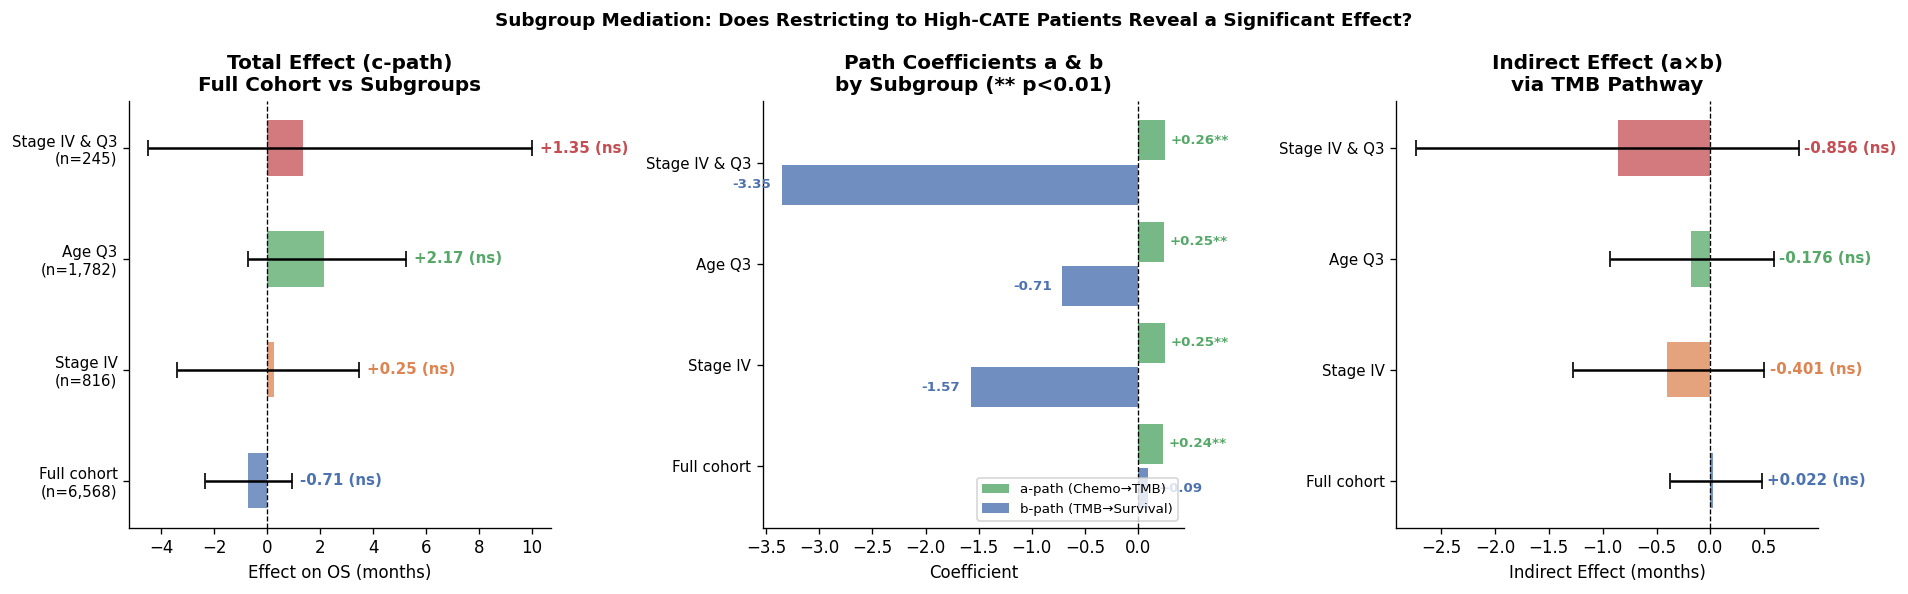


Key question: Is c-path significant in Stage IV or Age Q3?
  Full cohort: c = -0.71 mo → not significant (p=0.405)
  Stage IV: c = +0.25 mo → not significant (p=0.894)
  Age Q3: c = +2.17 mo → not significant (p=0.147)
  Stage IV & Q3: c = +1.35 mo → not significant (p=0.710)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names   = list(results.keys())
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Panel 1: Total effect (c) ────────────────────────────────────────────────
ax = axes[0]
for i, (name, r) in enumerate(results.items()):
    col = palette[i]
    ax.barh(i, r['c'], color=col, alpha=0.75, height=0.5)
    ax.errorbar(r['c'], i,
                xerr=[[r['c'] - r['c_lo']], [r['c_hi'] - r['c']]],
                fmt='none', color='black', capsize=5, lw=1.5)
    sig = '**' if r['c_p'] < 0.01 else ('*' if r['c_p'] < 0.05 else 'ns')
    x_label = max(r['c_hi'], r['c']) + 0.3
    ax.text(x_label, i, f'{r["c"]:+.2f} ({sig})',
            va='center', fontsize=9, fontweight='bold', color=col)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([f'{n}\n(n={results[n]["n"]:,})' for n in names], fontsize=9)
ax.set_xlabel('Effect on OS (months)')
ax.set_title('Total Effect (c-path)\nFull Cohort vs Subgroups', fontweight='bold')

# ── Panel 2: a-path and b-path — horizontal, same orientation as panels 1 & 3
ax = axes[1]
h = 0.22  # half-height of each bar pair
for i, (name, r) in enumerate(results.items()):
    # a-path (green) — upper slot
    ax.barh(i + h, r['a'], height=h*1.8, color='#55A868', alpha=0.8,
            label='a-path (Chemo→TMB)' if i == 0 else '')
    sig_a = '**' if r['a_p'] < 0.01 else ('*' if r['a_p'] < 0.05 else '')
    ax.text(r['a'] + 0.05, i + h, f'{r["a"]:+.2f}{sig_a}',
            va='center', fontsize=8, color='#55A868', fontweight='bold')
    # b-path (blue) — lower slot
    ax.barh(i - h, r['b'], height=h*1.8, color='#4C72B0', alpha=0.8,
            label='b-path (TMB→Survival)' if i == 0 else '')
    sig_b = '**' if r['b_p'] < 0.01 else ('*' if r['b_p'] < 0.05 else '')
    x_b = (r['b'] + 0.1) if r['b'] >= 0 else (r['b'] - 0.1)
    ax.text(x_b, i - h, f'{r["b"]:+.2f}{sig_b}',
            va='center', fontsize=8, color='#4C72B0', fontweight='bold',
            ha='left' if r['b'] >= 0 else 'right')

ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n for n in names], fontsize=9)
ax.set_xlabel('Coefficient')
ax.set_title('Path Coefficients a & b\nby Subgroup (** p<0.01)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# ── Panel 3: Indirect effect (a×b) ──────────────────────────────────────────
ax = axes[2]
for i, (name, r) in enumerate(results.items()):
    col = palette[i]
    ax.barh(i, r['ie'], color=col, alpha=0.75, height=0.5)
    ax.errorbar(r['ie'], i,
                xerr=[[r['ie'] - r['ie_lo']], [r['ie_hi'] - r['ie']]],
                fmt='none', color='black', capsize=5, lw=1.5)
    ci_cross = r['ie_lo'] <= 0 <= r['ie_hi']
    sig_label = 'ns' if ci_cross else '*'
    x_label = max(r['ie_hi'], r['ie']) + 0.05
    ax.text(x_label, i, f'{r["ie"]:+.3f} ({sig_label})',
            va='center', fontsize=9, color=col, fontweight='bold')

ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n for n in names], fontsize=9)
ax.set_xlabel('Indirect Effect (months)')
ax.set_title('Indirect Effect (a×b)\nvia TMB Pathway', fontweight='bold')

plt.suptitle('Subgroup Mediation: Does Restricting to High-CATE Patients Reveal a Significant Effect?',
             fontweight='bold', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '04_subgroup_mediation.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey question: Is c-path significant in Stage IV or Age Q3?')
for name, r in results.items():
    sig = 'SIGNIFICANT ✓' if r['c_p'] < 0.05 else f'not significant (p={r["c_p"]:.3f})'
    print(f'  {name}: c = {r["c"]:+.2f} mo → {sig}')

## Summary and Key Takeaways

### Results

| Effect | Estimate | 95% Bootstrap CI |
|--------|----------|------------------|
| Total Effect (TE) | See output above | See output above |
| Direct Effect (NDE) | Chemo → Survival, not through TMB | See output above |
| Indirect Effect (NIE) | Chemo → TMB → Survival | See output above |
| Proportion Mediated | IE / TE | See output above |

### Assumptions and Limitations

1. **No unmeasured treatment-outcome confounders**: Addressed by adjusting for {Age, Stage, Cancer Type}
2. **No unmeasured mediator-outcome confounders**: This is the key *untestable* assumption — sensitivity analysis in Cell 5 quantifies robustness
3. **No treatment-mediator interaction in the outcome model**: If Chemo × TMB interacts in predicting Survival, the product-of-coefficients decomposition is invalid — use the VanderWeele interaction term formula
4. **Linearity assumptions**: Both mediator and outcome models assumed linear; nonlinear relationships may require g-computation
5. **No cross-world independence violation**: The counterfactual Y(1, M(0)) requires comparing a patient who received chemo with their TMB value *had they not received chemo* — inherently hypothetical

### Pharma Relevance

Mediation analysis is essential for **mechanism of action (MoA) studies** in drug development:
- Does the drug work through its intended target (on-target mediation) or through off-target effects?
- For IO combinations: does chemo + IO work by boosting TMB (indirect) or by direct cytotoxicity + immune activation?
- Regulatory: FDA increasingly requests MoA evidence in drug approval packages